In [1]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 2.2 MB/s  0:00:26m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 3.2 MB/s  0:01:20m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, 
ConfusionMatrixDisplay, classification_report, RocCurveDisplay, roc_curve)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE=42
sns.set_theme(style = "whitegrid")

In [3]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

X_raw = adult.data.copy()
y_raw = adult.target.copy()

print("X shape:", X_raw.shape)
print("target shape:", y_raw.shape)

display(X_raw.head())
display(y_raw.head())

X shape: (48842, 14)
target shape: (48842,)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, str): ['<=50K', '>50K']

# binary ga o'tkazish kodi

In [7]:
X = X_raw.copy()

y = (
    y_raw.astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .eq(">50K")
    .astype(int)
)

print("Target Disturbutor")
display(y.value_counts().rename(index={0: "<=50K", 1:">50K"}))

Target Disturbutor


class
<=50K    37155
>50K     11687
Name: count, dtype: int64

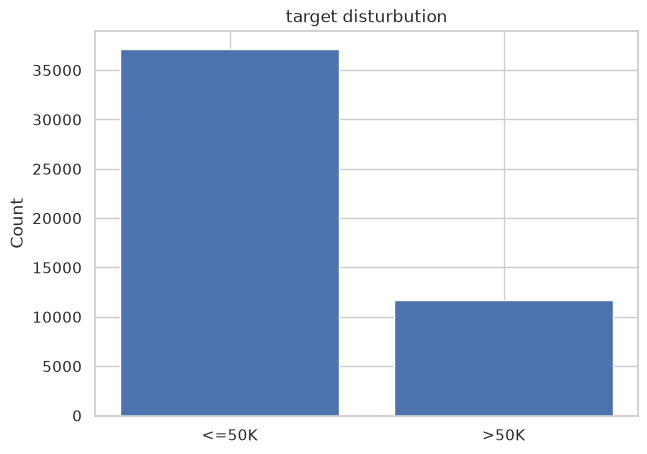

Class promotions:


,proportion
class,
<=50K,0.760718
>50K,0.239282


In [8]:
target_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["<=50K", ">50K"], target_counts.values)
plt.title("target disturbution")
plt.ylabel("Count")
plt.show()

print("Class promotions:")
display(
    y.value_counts(normalize="True")
    .sort_index()
    .rename(index={0: "<=50K", 1:">50K"})
    .to_frame("proportion")
)

In [9]:
print("Data types:")
display(X.dtypes.to_frame("dtype"))

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Data types:


,dtype
age,int64
workclass,category
fnlwgt,int64
education,category
education-num,int64
marital-status,category
occupation,category
relationship,category
race,category
sex,category


Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [10]:
missing = X.isna().sum().sort_values(ascending=True)

display(
    missing[missing > 0]
    .to_frame("missing_count")
    .assign(missing_percent = lambda d: 100 * d["missing_count"] / len(X))
)

print("Total missing values:", X.isna().sum().sum())

,missing_count,missing_percent
native-country,857,1.754637
workclass,2799,5.730724
occupation,2809,5.751198


Total missing values: 6465


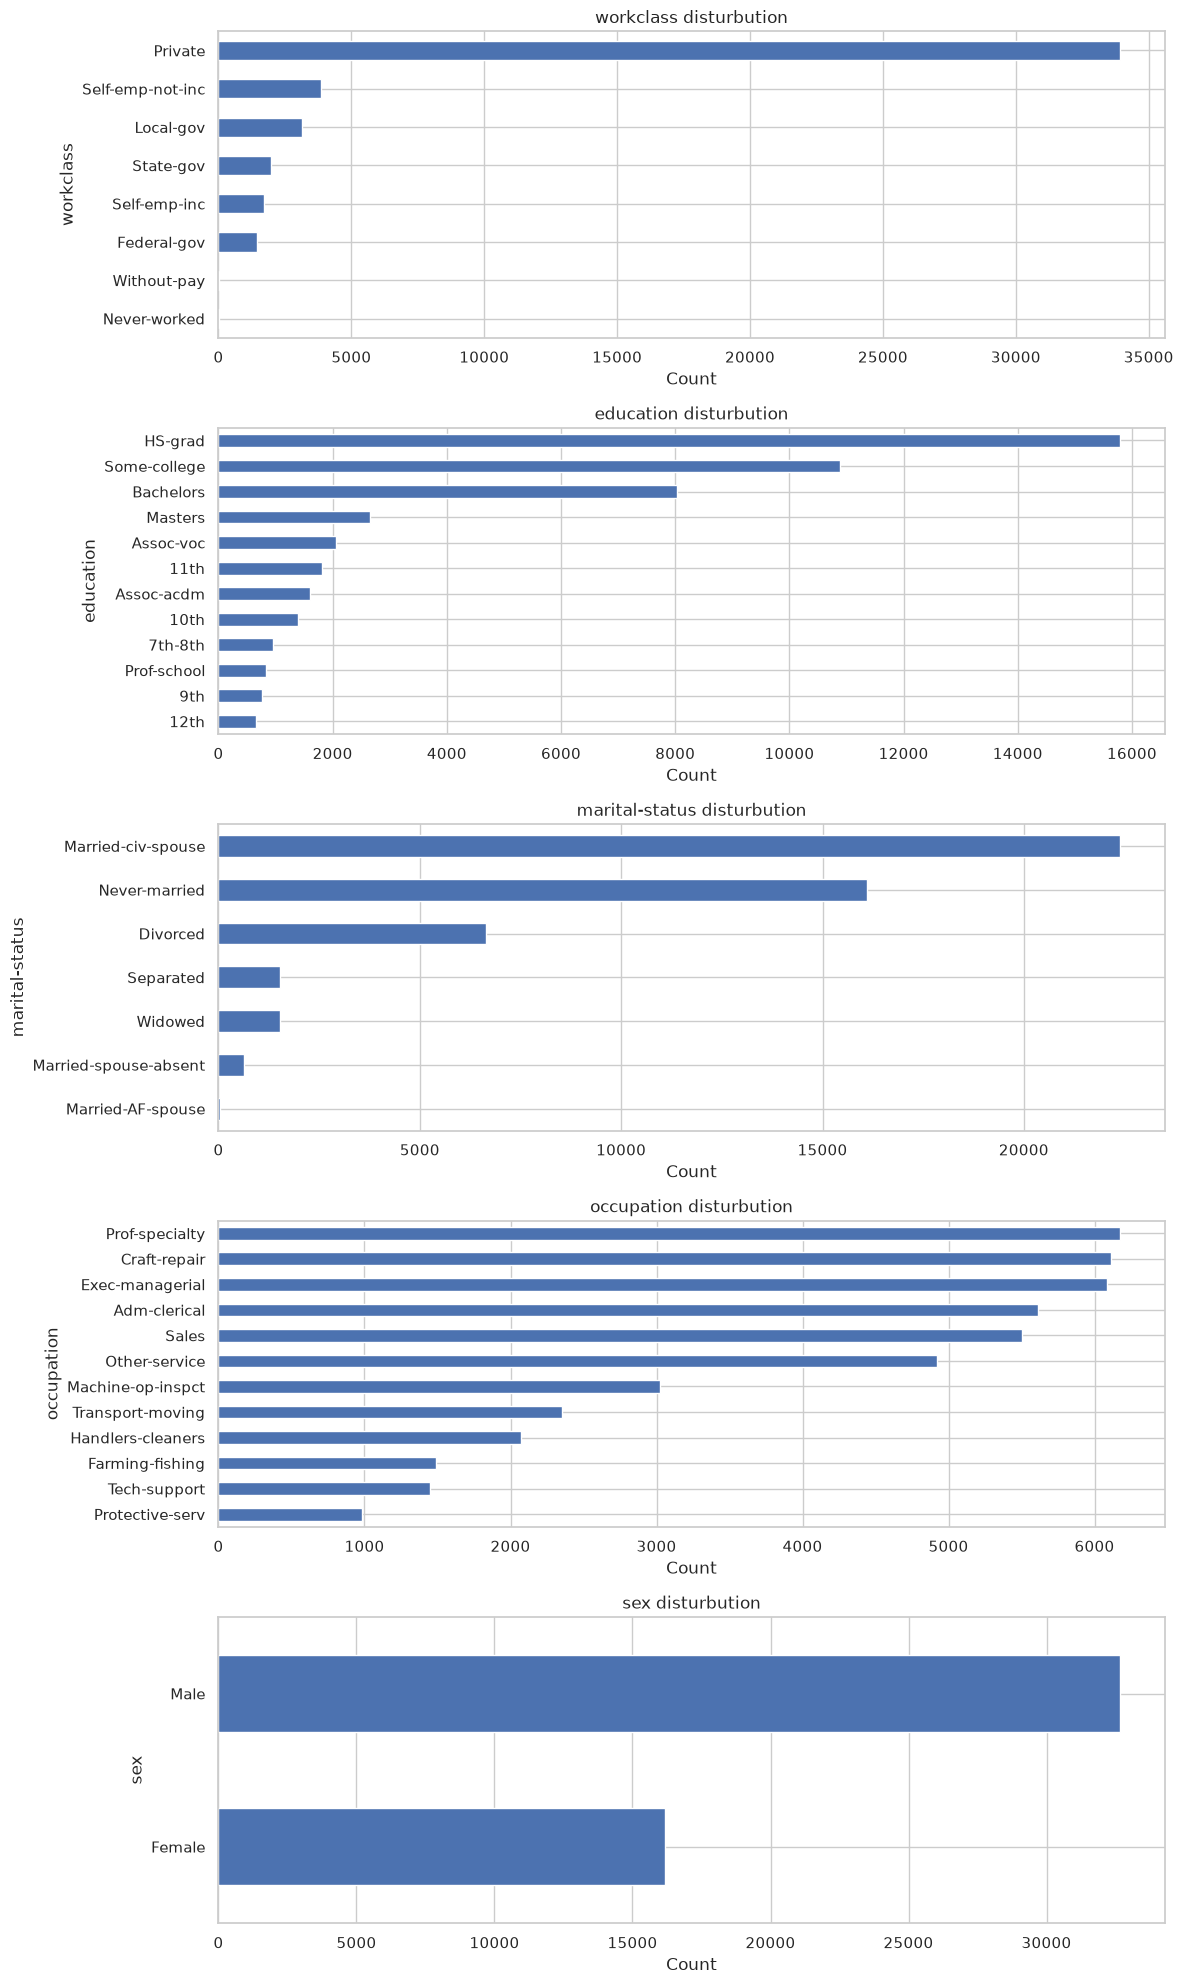

In [11]:
selected_cats = [
    col for col in ["workclass", "education", "marital-status", "occupation", "sex"]
    if col in X.columns
]
fig, axes = plt.subplots(
    len(selected_cats), 1,
    figsize=(12, 4 * len(selected_cats))
)

if len(selected_cats)==1:
    axes = [axes]

for ax, col in zip(axes, selected_cats):
    counts = X[col].astype(str).value_counts().head(12)
    counts.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"{col} disturbution")
    ax.set_xlabel("Count")


plt.tight_layout()
plt.show()

# Numerical disturbution

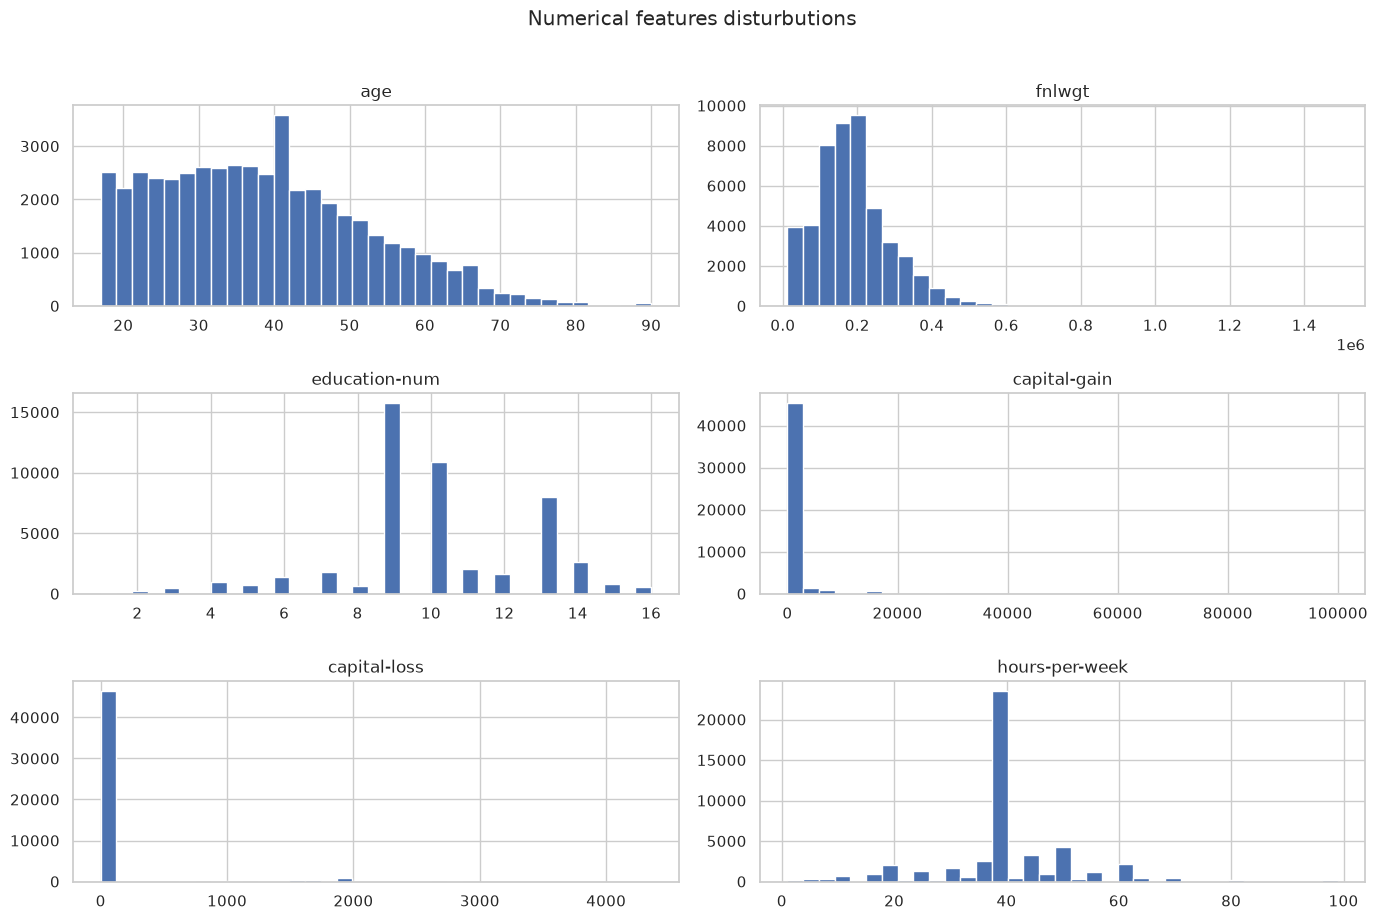

In [14]:
if numeric_features:
    X[numeric_features].hist(
        bins=35,
        figsize=(14, 9)
    )
    plt.suptitle('Numerical features disturbutions', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# X = X.replace()

# Datasetni bo'lish kodi

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (39073, 14)
Test: (9769, 14)
